<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.20);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 6px solid #38bdf8;
  margin: 0;
">
  Regresion lineal para predecir el coste del seguro medico
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Carga de librerias y configuracion
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Lectura del dataset
</h2>

In [2]:
df = pd.read_csv("../data/raw/medical_insurance_cost.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Dimensiones y nombres de columnas
</h4>

In [3]:
print("Shape del dataset:", df.shape)
print("Columnas:", df.columns.tolist())

Shape del dataset: (1338, 7)
Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Inspeccion inicial y calidad de datos
</h2>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Resumen rapido del dataset
</h4>

In [4]:
print("Dimensiones del dataset:", df.shape)

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("null_count"))

print("\nFilas duplicadas:", df.duplicated().sum())

Dimensiones del dataset: (1338, 7)

Valores nulos por columna:


,null_count
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0



Filas duplicadas: 1


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Informacion general de columnas
</h4>

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Resumen estadistico de variables numericas
</h4>

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


<div style="
  background-color: #0f172a;
  border-left: 6px solid #22c55e;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Lectura inicial</b>
<ul>
  <li>El dataset trae <b>1338 filas</b> y <b>7 columnas</b>, asi que es un tamaño comodo para explorar y modelar.</li>
  <li>La variable objetivo es <b>charges</b>, que es numerica. Por eso estamos ante un problema de <b>regresion</b>.</li>
  <li>Las variables <b>sex</b>, <b>smoker</b> y <b>region</b> son categoricas y luego habra que transformarlas a formato numerico.</li>
  <li>Antes de entrenar nada, conviene entender muy bien como se comporta <b>charges</b>, porque esa columna es la que marca el ritmo de todo el proyecto.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Analisis exploratorio de datos (EDA)
</h2>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #111827 0%, #1f2937 100%);
  padding: 12px 16px;
  border-radius: 10px;
  border-left: 6px solid #f59e0b;
  margin: 0;
">
Analisis de la variable objetivo: charges
</h3>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #f59e0b;
  margin: 0;
">
Resumen estadistico y asimetria de charges
</h4>

In [7]:
print("Resumen estadistico de charges:")
display(df["charges"].describe())

print("\nAsimetria de charges:")
print(round(df["charges"].skew(), 4))

Resumen estadistico de charges:


count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


Asimetria de charges:
1.5159


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #f59e0b;
  margin: 0;
">
📈 Histograma de la variable objetivo
</h4>

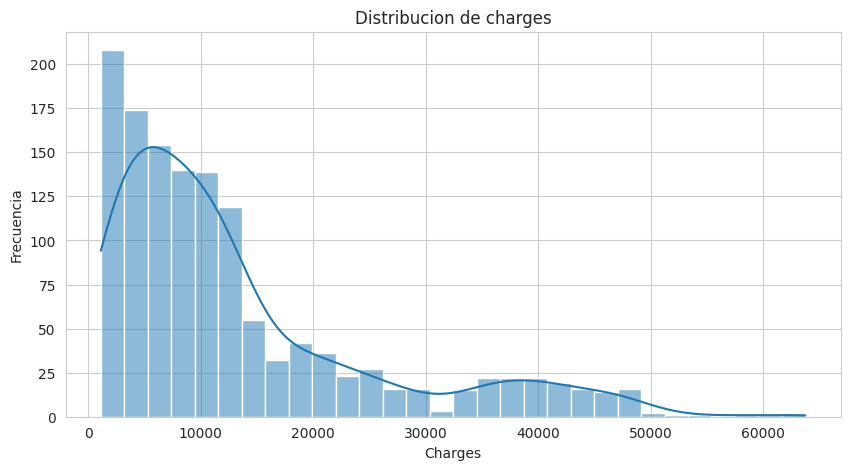

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="charges", kde=True)
plt.title("Distribucion de charges")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")
plt.show()

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #f59e0b;
  margin: 0;
">
📈 Boxplot de la variable objetivo
</h4>

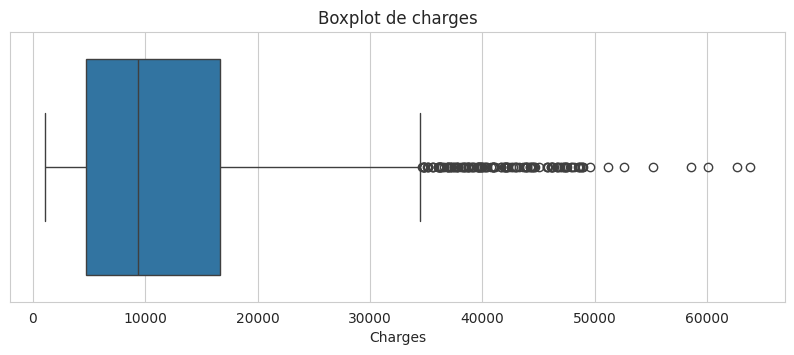

In [9]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(data=df, x="charges")
plt.title("Boxplot de charges")
plt.xlabel("Charges")
plt.show()

<div style="
  background-color: #111827;
  border-left: 6px solid #f59e0b;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Lo que puedo observar aca es:</b>
<ul>
  <li><b>charges</b> no esta repartida de forma pareja. La distribucion esta sesgada hacia la derecha.</li>
  <li>Eso significa que hay muchas personas con costes relativamente moderados y un grupo mas pequeño con costes bastante altos.</li>
  <li>En otras palabras no todos los clientes cuestan parecido. Hay casos caros que empujan la distribucion hacia arriba.</li>
  <li>Este detalle importa mucho, porque los modelos lineales suelen sufrir mas cuando hay valores altos muy separados del resto.</li>
</ul>
</div>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #111827 0%, #1f2937 100%);
  padding: 12px 16px;
  border-radius: 10px;
  border-left: 6px solid #22c55e;
  margin: 0;
">
Analisis univariado de variables numericas
</h3>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
Identificacion de variables numericas
</h4>

In [10]:
numeric_features = df.select_dtypes(include=["number"]).columns.tolist()
numeric_features

['age', 'bmi', 'children', 'charges']

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
📈 Histogramas de variables numericas
</h4>

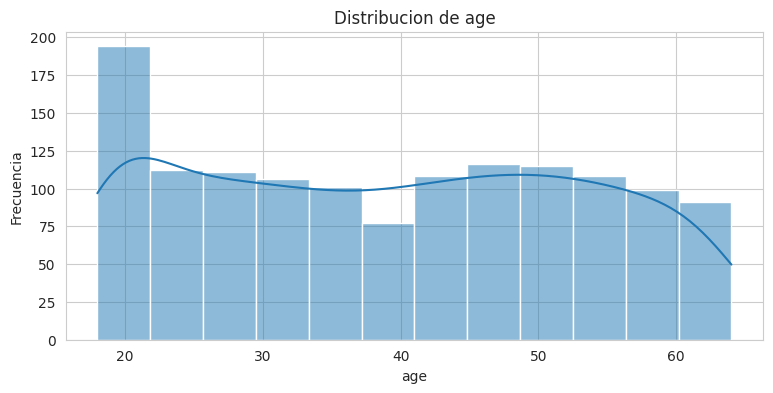

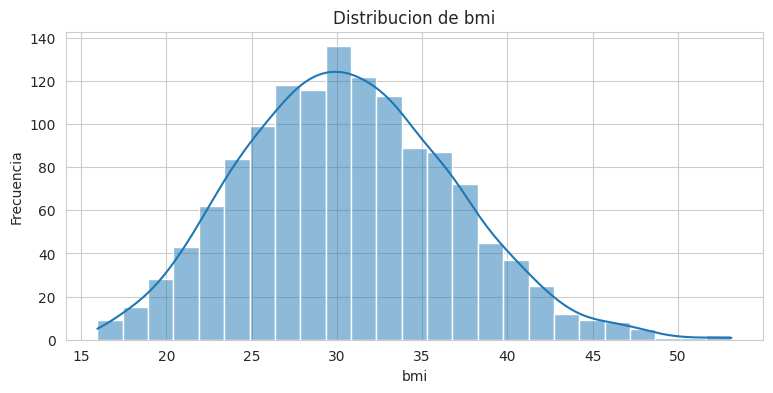

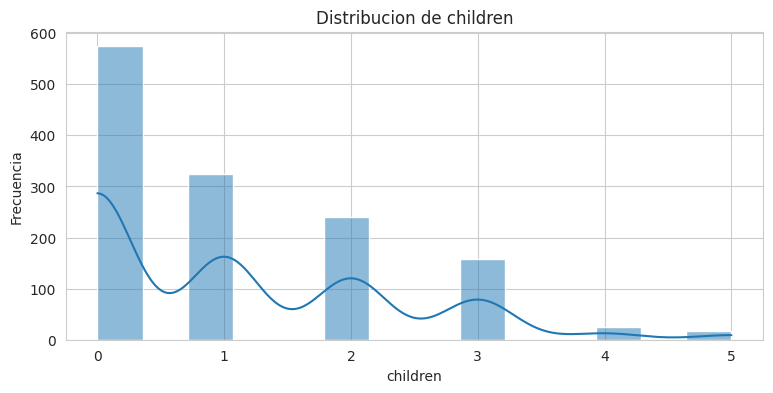

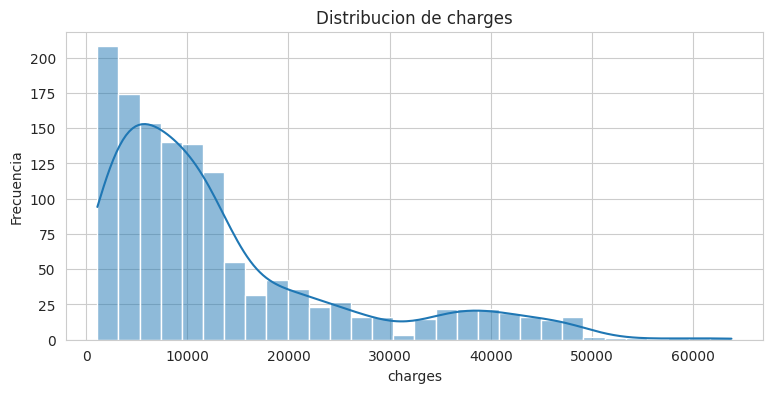

In [11]:
for col in numeric_features:
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribucion de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
📈 Boxplots de variables numericas
</h4>

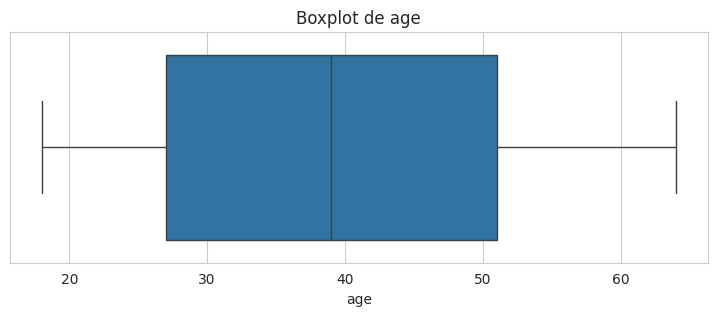

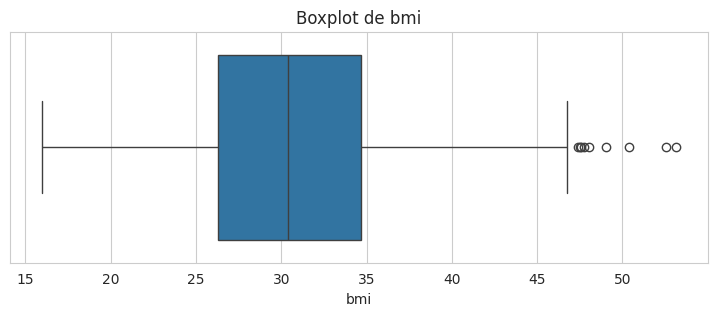

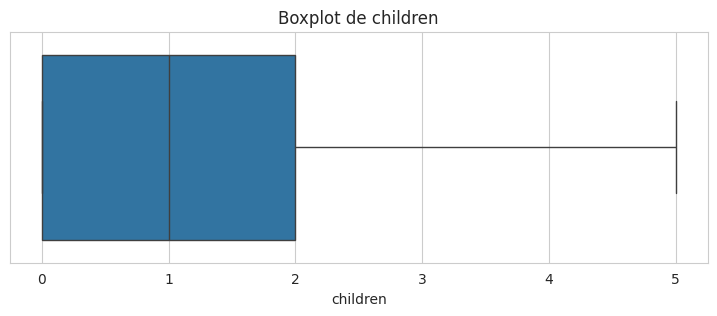

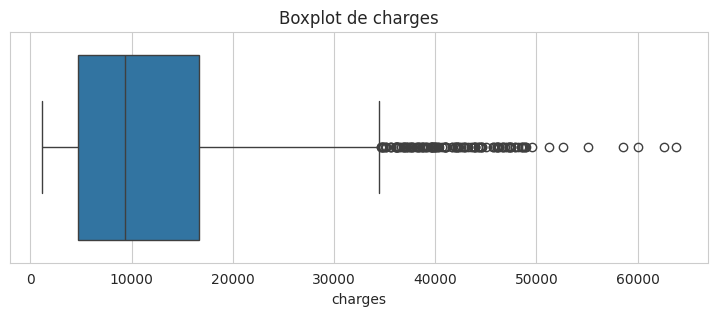

In [12]:
for col in numeric_features:
    plt.figure(figsize=(9, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #111827 0%, #1f2937 100%);
  padding: 12px 16px;
  border-radius: 10px;
  border-left: 6px solid #ec4899;
  margin: 0;
">
Analisis univariado de variables categoricas
</h3>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #ec4899;
  margin: 0;
">
Identificacion de variables categoricas
</h4>

In [13]:
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_features

['sex', 'smoker', 'region']

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #ec4899;
  margin: 0;
">
Frecuencias de variables categoricas
</h4>

In [14]:
for col in categorical_features:
    print(f"\nFrecuencias de {col}:")
    display(df[col].value_counts().to_frame("count"))


Frecuencias de sex:


,count
sex,
male,676
female,662



Frecuencias de smoker:


,count
smoker,
no,1064
yes,274



Frecuencias de region:


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #ec4899;
  margin: 0;
">
📈 Graficos de frecuencia para variables categoricas
</h4>

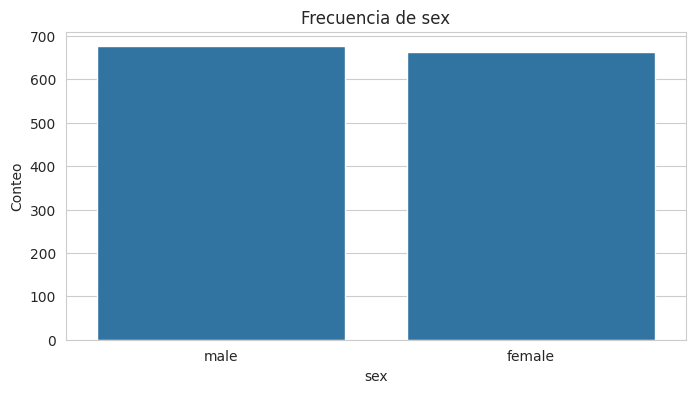

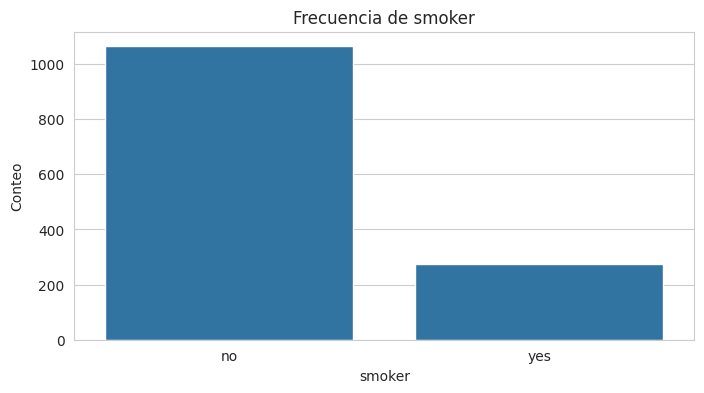

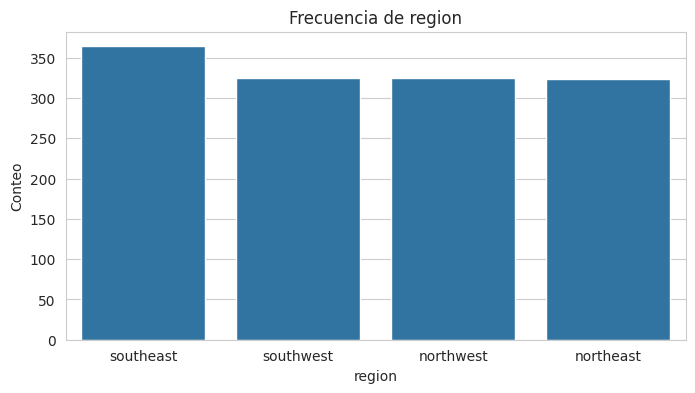

In [15]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Conteo")
    plt.xticks(rotation=0)
    plt.show()

<div style="
  background-color: #111827;
  border-left: 6px solid #38bdf8;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Primeras observaciones del analisis univariado</b>
<ul>
  <li>La edad esta bastante repartida y no parece haber un grupo demasiado dominante.</li>
  <li>El <b>BMI</b> muestra cierta dispersion y algun valor extremo, pero en general se mueve en rangos realistas para este tipo de problema.</li>
  <li>La variable <b>children</b> esta mas concentrada en valores bajos. Es decir, la mayoria de personas no tiene muchos dependientes.</li>
  <li>En las categoricas, <b>smoker</b> ya llama la atencion porque divide a la muestra en dos grupos con estilos de riesgo muy distintos.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Analisis bivariado: relacion entre las variables y charges
</h2>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #111827 0%, #1f2937 100%);
  padding: 12px 16px;
  border-radius: 10px;
  border-left: 6px solid #22c55e;
  margin: 0;
">
Relacion entre variables numericas y la variable objetivo
</h3>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
📈 Graficos de dispersion de variables numericas vs charges
</h4>

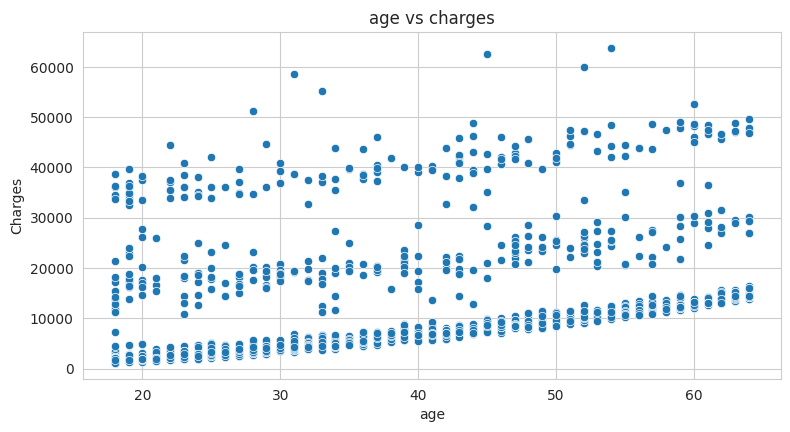

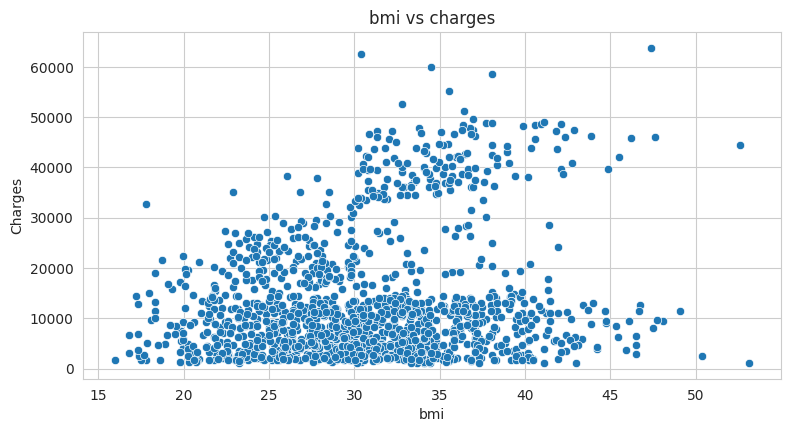

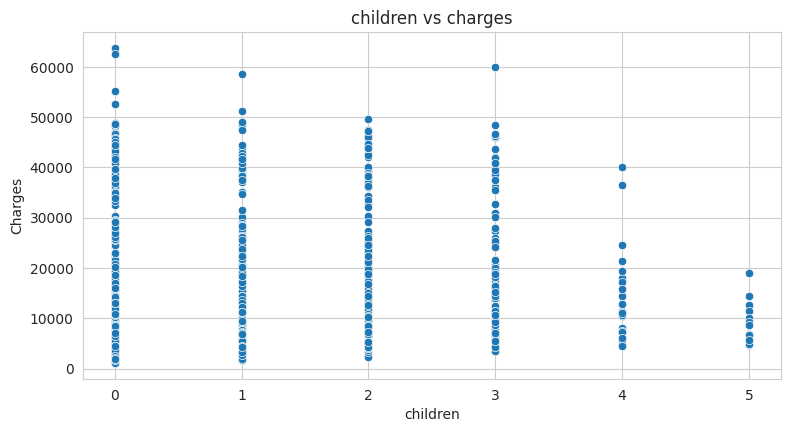

In [16]:
numeric_predictors = [col for col in numeric_features if col != "charges"]

for col in numeric_predictors:
    plt.figure(figsize=(9, 4.5))
    sns.scatterplot(data=df, x=col, y="charges")
    plt.title(f"{col} vs charges")
    plt.xlabel(col)
    plt.ylabel("Charges")
    plt.show()

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
Correlacion entre variables numericas
</h4>

In [17]:
corr_matrix = df[numeric_features].corr(numeric_only=True)
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #22c55e;
  margin: 0;
">
📈 Mapa de calor de correlacion
</h4>

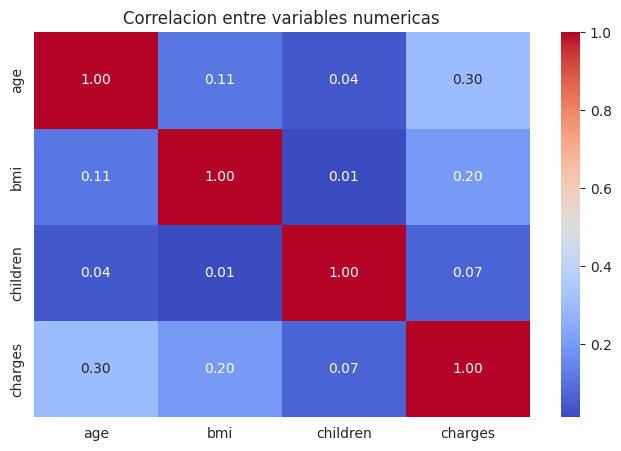

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlacion entre variables numericas")
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #111827 0%, #1f2937 100%);
  padding: 12px 16px;
  border-radius: 10px;
  border-left: 6px solid #ec4899;
  margin: 0;
">
Relacion entre variables categoricas y la variable objetivo
</h3>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #ec4899;
  margin: 0;
">
📈 Boxplots de variables categoricas vs charges
</h4>

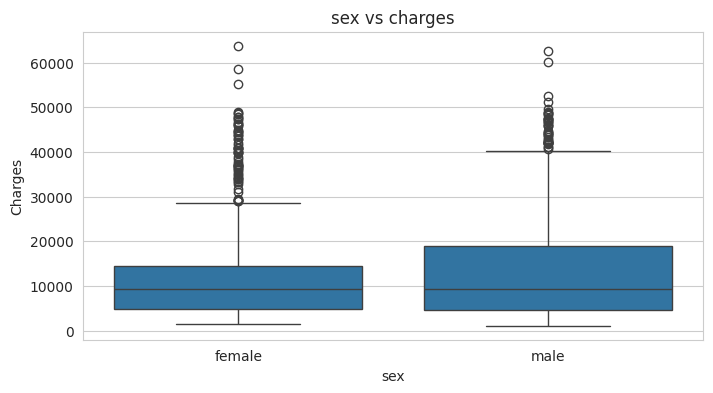

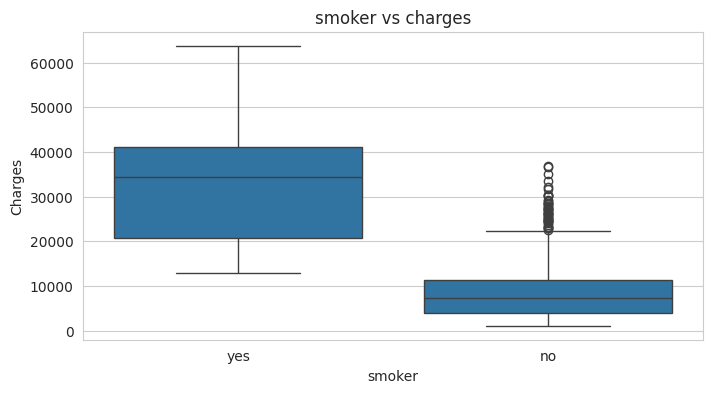

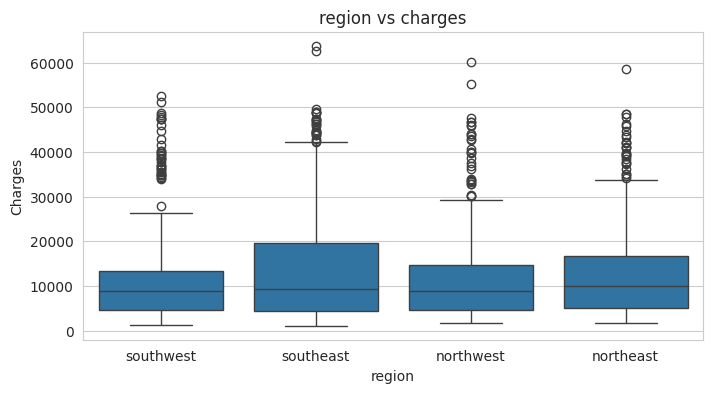

In [19]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y="charges")
    plt.title(f"{col} vs charges")
    plt.xlabel(col)
    plt.ylabel("Charges")
    plt.show()

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #ec4899;
  margin: 0;
">
Promedio de charges por categoria
</h4>

In [20]:
for col in categorical_features:
    print(f"\nPromedio de charges por {col}:")
    display(
        df.groupby(col, observed=False)["charges"]
          .mean()
          .sort_values(ascending=False)
          .round(2)
          .to_frame("mean_charges")
    )


Promedio de charges por sex:


,mean_charges
sex,
male,13956.75
female,12569.58



Promedio de charges por smoker:


,mean_charges
smoker,
yes,32050.23
no,8434.27



Promedio de charges por region:


,mean_charges
region,
southeast,14735.41
northeast,13406.38
northwest,12417.58
southwest,12346.94


<div style="
  background-color: #111827;
  border-left: 6px solid #38bdf8;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Lo que interpreto de esto es:</b>
<ul>
  <li><b>Smoker</b> es, con mucha diferencia, la variable que mas separa los costes. No es un detalle menor: cambia totalmente la escala del gasto.</li>
  <li><b>Age</b> tambien muestra una relacion positiva con <b>charges</b>: a mayor edad, en general aparece un coste mayor.</li>
  <li><b>BMI</b> no parece igual de limpio para todos los casos, pero en los valores altos se empieza a notar mas presion sobre el coste.</li>
  <li><b>Region</b> y <b>sex</b> parecen tener un peso bastante menor comparados con el habito de fumar.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusiones del EDA
</h2>

<div style="
  background-color: #111827;
  border-left: 6px solid #38bdf8;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Resumen del EDA</b>
<ul>
  <li>La variable objetivo <b>charges</b> esta sesgada hacia valores altos, asi que el problema no es tan simple como ajustar una recta y ya.</li>
  <li><b>Smoker</b> domina claramente el comportamiento del coste. Es la primera variable que hay que mirar cuando se quiere explicar por que una prima sube tanto.</li>
  <li><b>Age</b> aporta una señal bastante clara y <b>BMI</b> parece ganar importancia sobre todo cuando se combina con otros factores de riesgo.</li>
  <li>Con este panorama, tiene sentido arrancar con un baseline lineal y luego probar una mejora que capture mejor el efecto del tabaquismo sobre el coste.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Preparacion de los datos para Machine Learning
</h2>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Separacion entre variables predictoras y variable objetivo
</h4>

In [21]:
X = df.drop(columns="charges")
y = df["charges"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1338, 6)
Dimensiones de y: (1338,)


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Division del dataset en entrenamiento y prueba
</h4>

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1070, 6)
X_test : (268, 6)
y_train: (1070,)
y_test : (268,)


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Identificacion de variables numericas y categoricas para el pipeline
</h4>

In [23]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Variables numericas:", numeric_features)
print("Variables categoricas:", categorical_features)

Variables numericas: ['age', 'bmi', 'children']
Variables categoricas: ['sex', 'smoker', 'region']


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Definicion del preprocesamiento
</h4>

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Construccion del transformador de columnas
</h4>

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

<div style="
  background-color: #0f172a;
  border-left: 6px solid #22c55e;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Por que usar un pipeline</b>
<ul>
  <li>Porque mantiene el flujo ordenado: primero transforma, luego entrena.</li>
  <li>Porque evita errores tontos al repetir pasos manuales sobre train y test.</li>
  <li>Porque deja el notebook mas profesional y mas facil de explicar.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Modelo baseline: Linear Regression
</h2>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Construccion del pipeline completo
</h4>

In [26]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Entrenamiento del modelo baseline
</h4>

In [27]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Predicciones del modelo baseline
</h4>

In [28]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Funcion para evaluar modelos de regresion
</h4>

In [29]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return pd.Series({
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "R2": r2_score(y_true, y_pred)
    })

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Evaluacion del modelo baseline
</h4>

In [30]:
baseline_train_metrics = regression_metrics(y_train, y_train_pred)
baseline_test_metrics = regression_metrics(y_test, y_test_pred)

baseline_results = pd.DataFrame({
    "Train": baseline_train_metrics.round(4),
    "Test": baseline_test_metrics.round(4)
})

baseline_results

,Train,Test
MAE,4.208235e+03,4.181194e+03
MSE,3.727768e+07,3.359692e+07
RMSE,6.105545e+03,5.796285e+03
R2,7.417000e-01,7.836000e-01


<div style="
  background-color: #111827;
  border-left: 6px solid #38bdf8;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Como leer estas metricas sin complicarse</b>
<ul>
  <li><b>MAE</b> dice cuanto se equivoca el modelo en promedio.</li>
  <li><b>RMSE</b> castiga mas los errores grandes. Si este numero sube mucho, suele ser una pista de que los casos extremos le cuestan al modelo.</li>
  <li><b>R2</b> indica cuanto de la variacion de <b>charges</b> logra explicar el modelo.</li>
</ul>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Comparacion entre valores reales y predichos
</h4>

In [31]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

comparison_df["Residual"] = comparison_df["Actual"] - comparison_df["Predicted"]
comparison_df.head(10)

,Actual,Predicted,Residual
0,9095.06825,8969.550274,125.517976
1,5272.17580,7068.747443,-1796.571643
2,29330.98315,36858.410912,-7527.427762
3,9301.89355,9454.678501,-152.784951
4,33750.29180,26973.173457,6777.118343
5,4536.25900,10864.113164,-6327.854164
6,2117.33885,170.280841,1947.058009
7,14210.53595,16903.450287,-2692.914337
8,3732.62510,1092.430936,2640.194164
9,10264.44210,11218.343184,-953.901084


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
📈 Grafico de valores reales vs predichos
</h4>

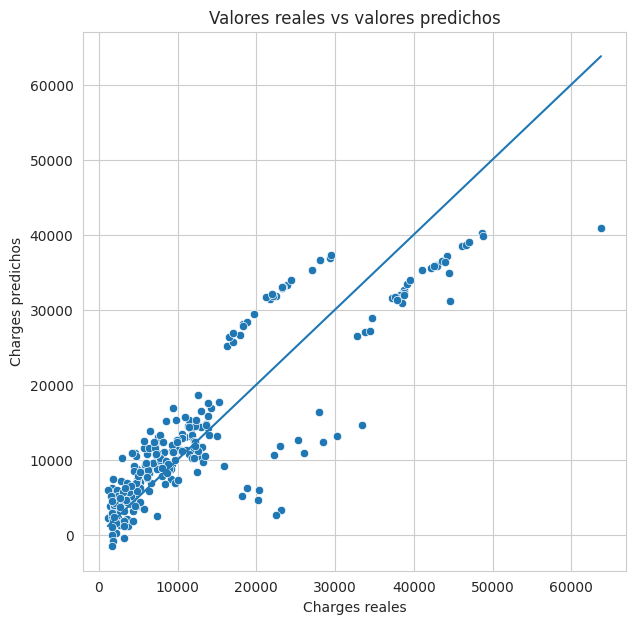

In [32]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.title("Valores reales vs valores predichos")
plt.xlabel("Charges reales")
plt.ylabel("Charges predichos")
plt.show()

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
📈 Distribucion de residuos
</h4>

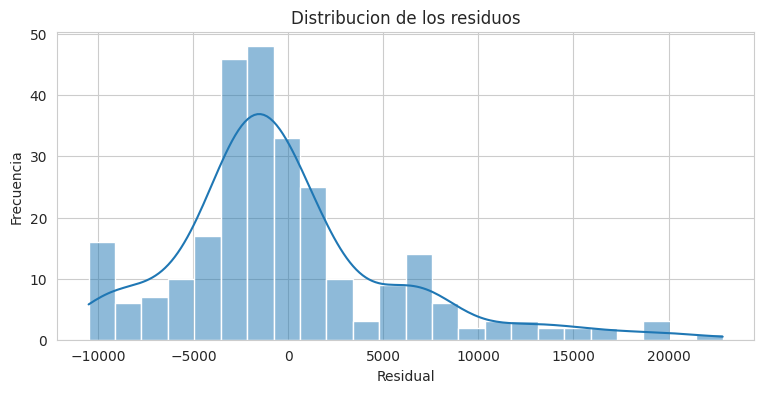

In [33]:
plt.figure(figsize=(9, 4))
sns.histplot(comparison_df["Residual"], kde=True)
plt.title("Distribucion de los residuos")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

<div style="
  background-color: #0f172a;
  border-left: 6px solid #f59e0b;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>En resumen:</b>
<ul>
  <li>El modelo base funciona bastante bien como primer intento.</li>
  <li>Sin embargo, sigue costándole predecir con precisión los casos más caros.</li>
  <li>Esto sugiere que el coste del seguro no se comporta de forma totalmente lineal en todos los perfiles.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Optimizacion del modelo
</h2>

<div style="
  background-color: #111827;
  border-left: 6px solid #22c55e;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Idea de la optimizacion</b>
<ul>
  <li>Al revisar el EDA he visto que <b>smoker</b> cambia muchisimo el coste.</li>
  <li>Tambien que <b>BMI</b> y <b>age</b> no se comportan igual para fumadores que para no fumadores.</li>
  <li>Por eso, en vez de cambiar a un modelo raro, intento mejorar la regresion lineal con <b>features de interaccion</b>.</li>
  <li>La meta es dejar que el modelo entienda mejor el efecto combinado entre fumar, edad y BMI.</li>
</ul>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Creacion de nuevas variables de interaccion
</h4>

In [34]:
df_optimized = df.copy()

df_optimized["smoker_num"] = (df_optimized["smoker"] == "yes").astype(int)
df_optimized["bmi_smoker"] = df_optimized["bmi"] * df_optimized["smoker_num"]
df_optimized["age_smoker"] = df_optimized["age"] * df_optimized["smoker_num"]

df_optimized.head()

,age,sex,bmi,children,smoker,region,charges,smoker_num,bmi_smoker,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,1,27.9,19
1,18,male,33.770,1,no,southeast,1725.55230,0,0.0,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0.0,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0.0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0.0,0


<div style="
  background-color: #0f172a;
  border-left: 6px solid #f59e0b;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Que significan estas columnas nuevas</b>
<ul>
  <li><b>smoker_num</b> convierte el habito de fumar en 1 y 0 para trabajar mas facilmente.</li>
  <li><b>bmi_smoker</b> ayuda a capturar si un BMI alto pesa mas cuando la persona fuma.</li>
  <li><b>age_smoker</b> ayuda a capturar si la edad se vuelve aun mas costosa dentro del grupo fumador.</li>
</ul>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Nuevo split para el modelo optimizado
</h4>

In [35]:
X_opt = df_optimized.drop(columns="charges")
y_opt = df_optimized["charges"]

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt,
    y_opt,
    test_size=0.20,
    random_state=42
)

numeric_features_opt = X_train_opt.select_dtypes(include=["number"]).columns.tolist()
categorical_features_opt = X_train_opt.select_dtypes(include=["object", "string"]).columns.tolist()

print("Variables numericas optimizadas:", numeric_features_opt)
print("Variables categoricas optimizadas:", categorical_features_opt)

Variables numericas optimizadas: ['age', 'bmi', 'children', 'smoker_num', 'bmi_smoker', 'age_smoker']
Variables categoricas optimizadas: ['sex', 'smoker', 'region']


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Preprocesamiento para el modelo optimizado
</h4>

In [36]:
numeric_transformer_opt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_opt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_opt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_opt, numeric_features_opt),
        ("cat", categorical_transformer_opt, categorical_features_opt)
    ]
)

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Entrenamiento del modelo optimizado
</h4>

In [37]:
optimized_model = Pipeline(steps=[
    ("preprocessor", preprocessor_opt),
    ("model", LinearRegression())
])

optimized_model.fit(X_train_opt, y_train_opt)

y_train_pred_opt = optimized_model.predict(X_train_opt)
y_test_pred_opt = optimized_model.predict(X_test_opt)

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Evaluacion del modelo optimizado
</h4>

In [38]:
optimized_train_metrics = regression_metrics(y_train_opt, y_train_pred_opt)
optimized_test_metrics = regression_metrics(y_test_opt, y_test_pred_opt)

optimized_results = pd.DataFrame({
    "Train": optimized_train_metrics.round(4),
    "Test": optimized_test_metrics.round(4)
})

optimized_results

,Train,Test
MAE,2.974956e+03,2.757759e+03
MSE,2.394908e+07,2.092261e+07
RMSE,4.893780e+03,4.574124e+03
R2,8.341000e-01,8.652000e-01


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Comparacion final entre modelos
</h4>

In [39]:
model_comparison = pd.DataFrame({
    "Baseline_Test": baseline_test_metrics.round(4),
    "Optimized_Test": optimized_test_metrics.round(4)
})

model_comparison

,Baseline_Test,Optimized_Test
MAE,4.181194e+03,2.757759e+03
MSE,3.359692e+07,2.092261e+07
RMSE,5.796285e+03,4.574124e+03
R2,7.836000e-01,8.652000e-01


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Diferencia de rendimiento en test
</h4>

In [40]:
(model_comparison["Optimized_Test"] - model_comparison["Baseline_Test"]).to_frame("Optimized - Baseline")

,Optimized - Baseline
MAE,-1.423435e+03
MSE,-1.267431e+07
RMSE,-1.222161e+03
R2,8.160000e-02


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Seleccion del mejor modelo
</h4>

In [41]:
if optimized_test_metrics["RMSE"] < baseline_test_metrics["RMSE"]:
    best_model_name = "LinearRegression con variables de interaccion"
    best_test_metrics = optimized_test_metrics
else:
    best_model_name = "LinearRegression baseline"
    best_test_metrics = baseline_test_metrics

print("Mejor modelo segun RMSE en test:", best_model_name)
display(best_test_metrics.round(4).to_frame("value"))

Mejor modelo segun RMSE en test: LinearRegression con variables de interaccion


,value
MAE,2.757759e+03
MSE,2.092261e+07
RMSE,4.574124e+03
R2,8.652000e-01


<div style="
  background-color: #0f172a;
  border-left: 6px solid #22c55e;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Lectura de la optimizacion</b>
<ul>
  <li>Aqui la mejora no vino de cambiar a un modelo mas sofisticado, sino de <b>darle al modelo una mejor forma de leer el problema</b>.</li>
  <li>Las interacciones ayudan a representar mejor que fumar no solo suma coste, sino que cambia como influyen otras variables.</li>
  <li>Eso encaja mucho mejor con la logica del negocio y con lo que se veia en el EDA.</li>
</ul>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Resumen final del proyecto
</h2>

In [42]:
summary_table = pd.DataFrame({
    "Modelo": ["LinearRegression baseline", "LinearRegression optimizado"],
    "MAE_test": [baseline_test_metrics["MAE"], optimized_test_metrics["MAE"]],
    "RMSE_test": [baseline_test_metrics["RMSE"], optimized_test_metrics["RMSE"]],
    "R2_test": [baseline_test_metrics["R2"], optimized_test_metrics["R2"]]
}).round(2)

summary_table

,Modelo,MAE_test,RMSE_test,R2_test
0,LinearRegression baseline,4181.19,5796.28,0.78
1,LinearRegression optimizado,2757.76,4574.12,0.87


<div style="
  background-color: #111827;
  border-left: 6px solid #38bdf8;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Conclusion final:</b>
<ul>
  <li>El modelo base ya consigue explicar bastante bien el coste del seguro.</li>
  <li>La variable que más influye es <b>smoker</b>, algo que ya se veía claramente en el análisis.</li>
  <li>La mejor mejora no fue cambiar de modelo, sino añadir variables que representaran mejor cómo se combinan algunos factores.</li>
  <li>Gracias a eso, el modelo final queda más sólido y mucho más fácil de justificar.</li>
</ul>
</div>

<div style="
  background-color: #0f172a;
  border-left: 6px solid #f59e0b;
  padding: 14px 16px;
  border-radius: 10px;
  color: #e5e7eb;
  line-height: 1.75;
  font-size: 16px;
">
<b>Cierre</b><br>
Si tuviera que resumir este proyecto en una sola frase, seria esta: <b>el coste del seguro no depende solo de variables aisladas, sino de como se combinan ciertos factores de riesgo, especialmente el tabaquismo</b>.
</div>